In [3]:
#Import packages needed for analysis
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.optimize import curve_fit
import csv

In [4]:
#data = [] 
with open('muon_data_1579.txt', 'r') as file: #import data from muon data 85
    r = csv.reader(file,delimiter=',')
    #csv_reader = csv.reader(file)
    for i, data in enumerate(r):
        if i==0: #first row is the times bin in nano-seconds 
            time = data
        else:    # second row is the pulse height information
            pulse=data
x = [float(ele) for ele in time] #Set up x array
y = [float(ele) for ele in pulse] #Set up y array

In [5]:
#Determine the location and value of the first maximum
ymax = max(y)
loc_max = y.index(ymax)

In [6]:
#Assign x value for the first maximum
xmax = x[loc_max]
xmax
t0 = xmax
print('ymax = ', ymax, '    loc_max = ', loc_max)

ymax =  1344.3531889915466     loc_max =  4880


In [7]:
#Determine the location and value of the second maximum
y2max = max(y[loc_max+50:])
loc2_max = y.index(y2max)
print('y2max = ', y2max, '   loc2_max = ', loc2_max)

y2max =  568.3053811788559    loc2_max =  5049


In [8]:
#Assign x value for the second maximum
x2max=x[loc2_max]
x2max

99.26240780097578

In [9]:
x_axis = np.arange(x[loc_max+20], x[loc2_max+100], 2.)
# x_axis

In [17]:
#Define function for fitting the muon track, where tt is set
def test(t, a, b, ts):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/743.)

In [19]:
#Design curve fit based on above function and muon data
param1, param_cov1 = curve_fit(test, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param1)
print(param_cov1)

[1481.36647629   61.47067338   13.69159606]
[[ 2.49300930e+02  9.74916139e-01 -2.32266209e+00]
 [ 9.74916139e-01  3.99556219e+00 -1.51111834e-01]
 [-2.32266209e+00 -1.51111834e-01  4.23558609e-02]]


In [44]:
#Display parameters associated with each value for the function
print("a = ", param1[0], " +/- ", param_cov1[0][0]) 
print("b = ", param1[1], " +/- ", param_cov1[1][1])
print("ts = ", param1[2], " +/- ", param_cov1[2][2])
apara = param1[0]
bpara = param1[1]
tspara = param1[2]

a =  1481.3664762947978  +/-  249.30093004896577
b =  61.47067337757649  +/-  3.995562193767123
ts =  13.691596061912714  +/-  0.042355860939347824


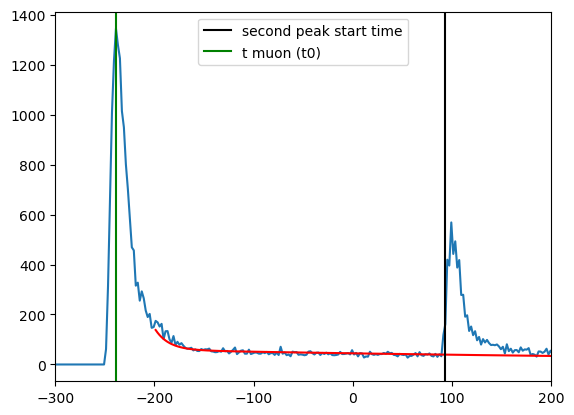

In [74]:
plt.plot(x[4500:6500], y[4500:6500])
plt.plot(x_axis,test(x_axis,param1[0],param1[1],param1[2]),'r') #plotting the test function
plt.axvline(93.26165770721491, color = 'k', label = "second peak start time") #plot the starting point for the second peak for integration
plt.axvline(-238.77984748093513, color = 'green', label = "t muon (t0)")
plt.xlim(-300, 200)
plt.legend()
plt.show()

In [110]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
#    if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 0 and x[i] < 250:
 #       print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (93.26165770721491, 161.78617572784424)
        
#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
  #       print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-238.77984748093513, 1344.3531889915466)
t0 = -238.77984748093513

#Integrate for 20 bins
bins = np.arange(93, 112)
sum = 0
for i in bins:
    #print(x[i+4953], y[i+4953])
    sum += y[i+4953] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):", sum)

#Integrate for 45 bins
bins2 = np.arange(93, 137)
sum2 = 0
for i in bins2:
   # print(y[i+4500])
    sum2 += y[i+4953] - (apara*np.exp(-(i-t0)/tspara) + bpara*np.exp(-(i-t0)/743.))
print("Number of PEs (photoelectron):", sum2)

Number of PEs (photoelectron): 4315.184894856257
Number of PEs (photoelectron): 5063.305405681269


In [78]:
#Define function for fitting the muon track, where tt is undefined
def test2(t,a,b,ts,tt):
    return (np.heaviside(t-t0, 1.))*a*np.exp(-(t-t0)/ts) + (np.heaviside(t-t0,1.))*b*np.exp(-(t-t0)/tt)

In [28]:
#Design curve fit based on above function and muon data
param2, param_cov2 = curve_fit(test2, x[loc_max+1:loc2_max-15], y[loc_max+1:loc2_max-15])
print(param2)
print(param_cov2)

[1479.14531314   76.16270456   13.28256084  376.78785719]
[[ 2.49602762e+02 -5.48925044e+00 -2.07739622e+00  7.88758745e+01]
 [-5.48925044e+00  3.33846231e+01 -9.12651184e-01 -3.36042486e+02]
 [-2.07739622e+00 -9.12651184e-01  5.96201187e-02  8.65114323e+00]
 [ 7.88758745e+01 -3.36042486e+02  8.65114323e+00  4.08653270e+03]]


In [82]:
#Display parameters associated with each value for the function
print("t = ", param2[0], " +/- ", param_cov2[0][0]) 
print("a = ", param2[1], " +/- ", param_cov2[1][1])
print("b = ", param2[2], " +/- ", param_cov2[2][2])
print("ts = ", param2[3], " +/- ", param_cov2[3][3])
apara2 = param2[0]
bpara2 = param2[1]
tspara2 = param2[2]
ttpara = param2[3]

t =  1479.1453131440446  +/-  249.60276247330222
a =  76.16270455556142  +/-  33.38462312053609
b =  13.282560837675566  +/-  0.05962011874267742
ts =  376.78785719322394  +/-  4086.532700237403


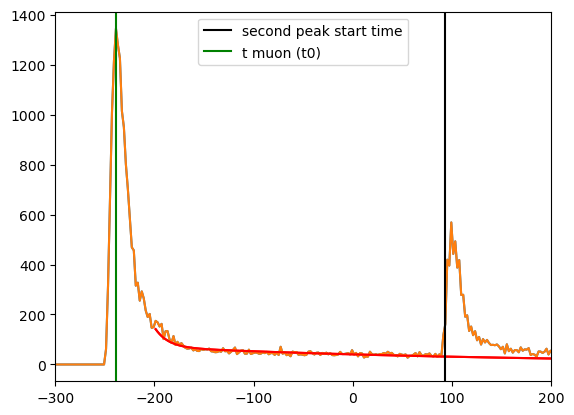

In [84]:
plt.plot(x[4500:5500], y[4500:5500])
plt.plot(x_axis, test2(x_axis,param2[0],param2[1], param2[2], param2[3]),'r') #plotting the test function
plt.plot(x[4500:5500], y[4500:5500])
plt.plot(x_axis, test2(x_axis,param2[0],param2[1], param2[2], param2[3]),'r') #plotting the test function
plt.axvline(93.26165770721491, color = 'k', label = "second peak start time") #plot the starting point for the second peak for integration
plt.axvline(-238.77984748093513, color = 'green', label = "t muon (t0)")
plt.legend()
plt.xlim(-300, 200)
plt.show()

In [112]:
#Integrate the plot above by finding the starting point of the second peak, which is the starting point for three consecutive slopes before the second peak
#and subtracting the red exponential from the second peak for (40 and 90 ns) 2 ns equals a bin 

#Loop to find the starting point of the secondary peak
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] > y[i-1] and y[i] < y[i+1] and y[i] < y2max and x[i] > 1000:
  #      print(x[i] , y[i], i)
#Based on the above code the starting point of the secondary peak should be (1337.4171771471447, 2.3070671558380127)

#Loop to find the starting point of the primary peak (t0) which is t muon for the fitting equation below
#o = np.arange(0, len(x)-1);
#for i in o:
 #   if y[i] == np.max(y):
         #print(x[i] , y[i], i)
#Based on the above code the starting point of the primary peak should be (-216.77709713714103, 956.901932477951)
#t02 = -216.77709713714103


#bins3 = np.arange(1337, 1356)
sum3 = 0
for i in bins:
   # print(y[i+4500])
    sum3 += y[i+4953] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):", sum3)

sum4 = 0
for i in bins2:
    sum4 += y[i+4953] - (apara2*np.exp(-(i-t0)/tspara2) + bpara2*np.exp(-(i-t0)/ttpara))
print("Number of PEs (photoelectron):", sum4)

Number of PEs (photoelectron): 4467.699044254921
Number of PEs (photoelectron): 5431.831886219617
